<a href="https://colab.research.google.com/github/bhumikashiriya-dot/Lnt-task-/blob/main/Task%202%20scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

(x, y), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()
x, x_test = x.reshape(-1, 784) / 255.0, x_test.reshape(-1, 784) / 255.0
x_train, y_train = x[:10000], y[:10000]      # small train set -> overfitting is easy to see
x_val, y_val = x[-10000:], y[-10000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [7]:
def build(units=512, n_layers=2, reg=None, dropout=0.0, bn=False):
    m = keras.Sequential([keras.Input(shape=(784,))])
    for _ in range(n_layers):
        m.add(layers.Dense(units, kernel_regularizer=reg))
        if bn: m.add(layers.BatchNormalization())
        m.add(layers.Activation("relu"))
        if dropout: m.add(layers.Dropout(dropout))
    m.add(layers.Dense(10, activation="softmax"))
    m.compile("adam", "sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

results, hist = [], {}

def run(name, epochs=30, early=False, **kw):
    keras.utils.set_random_seed(42)
    m = build(**kw)
    cb = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)] if early else []
    h = m.fit(x_train, y_train, epochs=epochs, batch_size=128,
              validation_data=(x_val, y_val), callbacks=cb, verbose=0)
    tr = m.evaluate(x_train, y_train, verbose=0)[1]
    va = m.evaluate(x_val, y_val, verbose=0)[1]
    te = m.evaluate(x_test, y_test, verbose=0)[1]
    w = m.layers[0].get_weights()[0]
    results.append(dict(model=name, train_acc=round(tr, 4), val_acc=round(va, 4), test_acc=round(te, 4),
                        gap=round(tr - va, 4), epochs_run=len(h.history["loss"]),
                        near_zero_weights=f"{np.mean(np.abs(w) < 1e-3):.0%}"))
    hist[name] = h.history
    print(name, "| train", round(tr, 4), "| val", round(va, 4), flush=True)

In [8]:
run("Underfit (tiny model)", units=4, n_layers=1)                    # high bias
run("Baseline")                                                      # high variance (overfits)
run("L1 (1e-5)", reg=regularizers.l1(1e-5))
run("L2 (1e-3)", reg=regularizers.l2(1e-3))
run("Dropout (0.3)", dropout=0.3)
run("BatchNorm", bn=True)
run("Early stopping", early=True)
run("Combined", reg=regularizers.l2(1e-4), dropout=0.3, bn=True, early=True)

Underfit (tiny model) | train 0.7117 | val 0.685
Baseline | train 0.9486 | val 0.854
L1 (1e-5) | train 0.9483 | val 0.8585
L2 (1e-3) | train 0.9103 | val 0.851
Dropout (0.3) | train 0.9411 | val 0.8675
BatchNorm | train 0.9454 | val 0.834
Early stopping | train 0.8761 | val 0.8459
Combined | train 0.9133 | val 0.8599


,model,train_acc,val_acc,test_acc,gap,epochs_run,near_zero_weights
0,Underfit (tiny model),0.7117,0.6850,0.6869,0.0267,30,0%
1,Baseline,0.9486,0.8540,0.8465,0.0946,30,1%
2,L1 (1e-5),0.9483,0.8585,0.8465,0.0898,30,36%
3,L2 (1e-3),0.9103,0.8510,0.8441,0.0593,30,45%
4,Dropout (0.3),0.9411,0.8675,0.8610,0.0736,30,1%
5,BatchNorm,0.9454,0.8340,0.8284,0.1114,30,1%
6,Early stopping,0.8761,0.8459,0.8378,0.0302,7,1%
7,Combined,0.9133,0.8599,0.8507,0.0534,10,2%


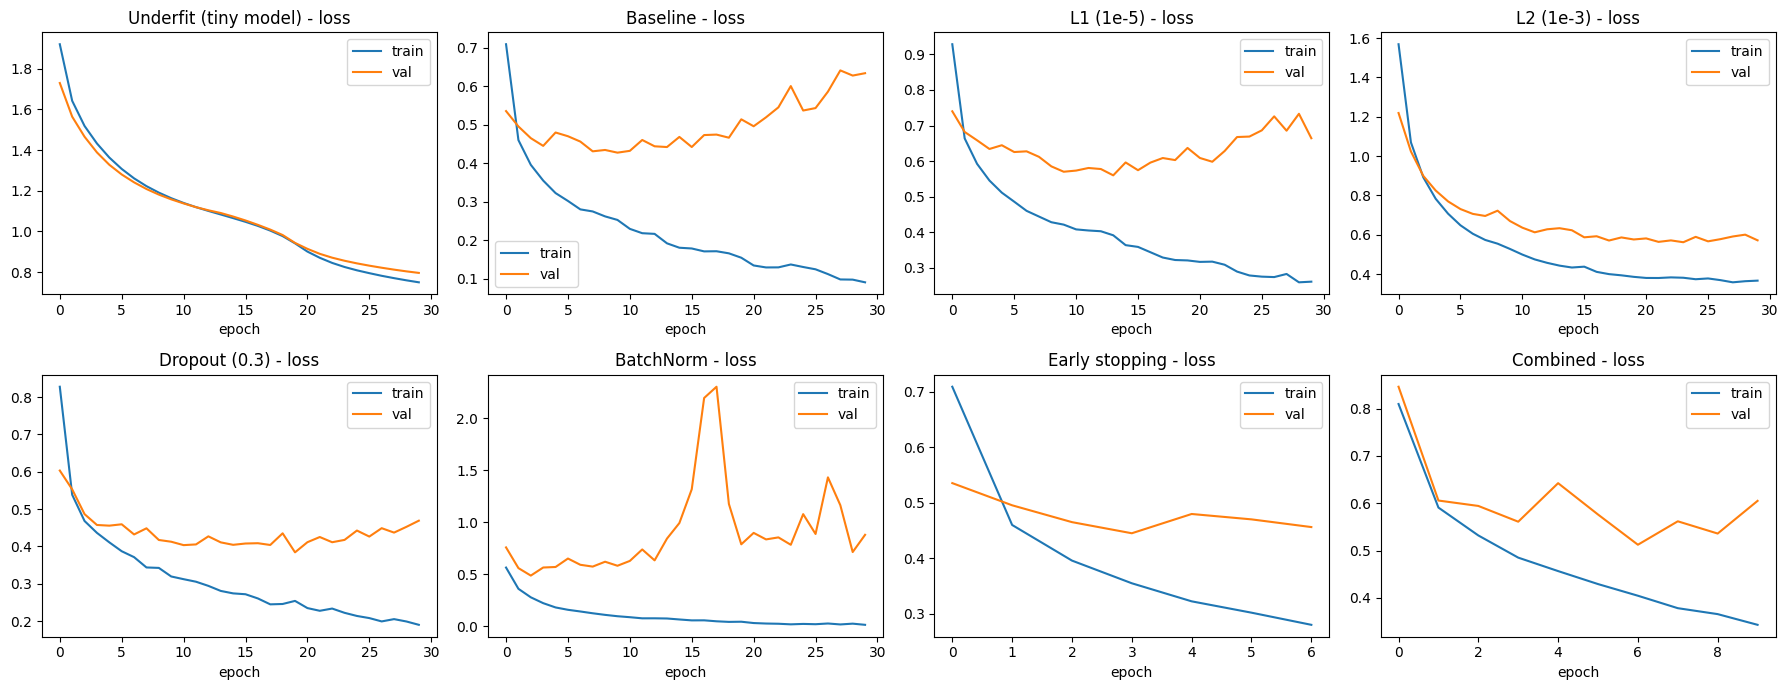

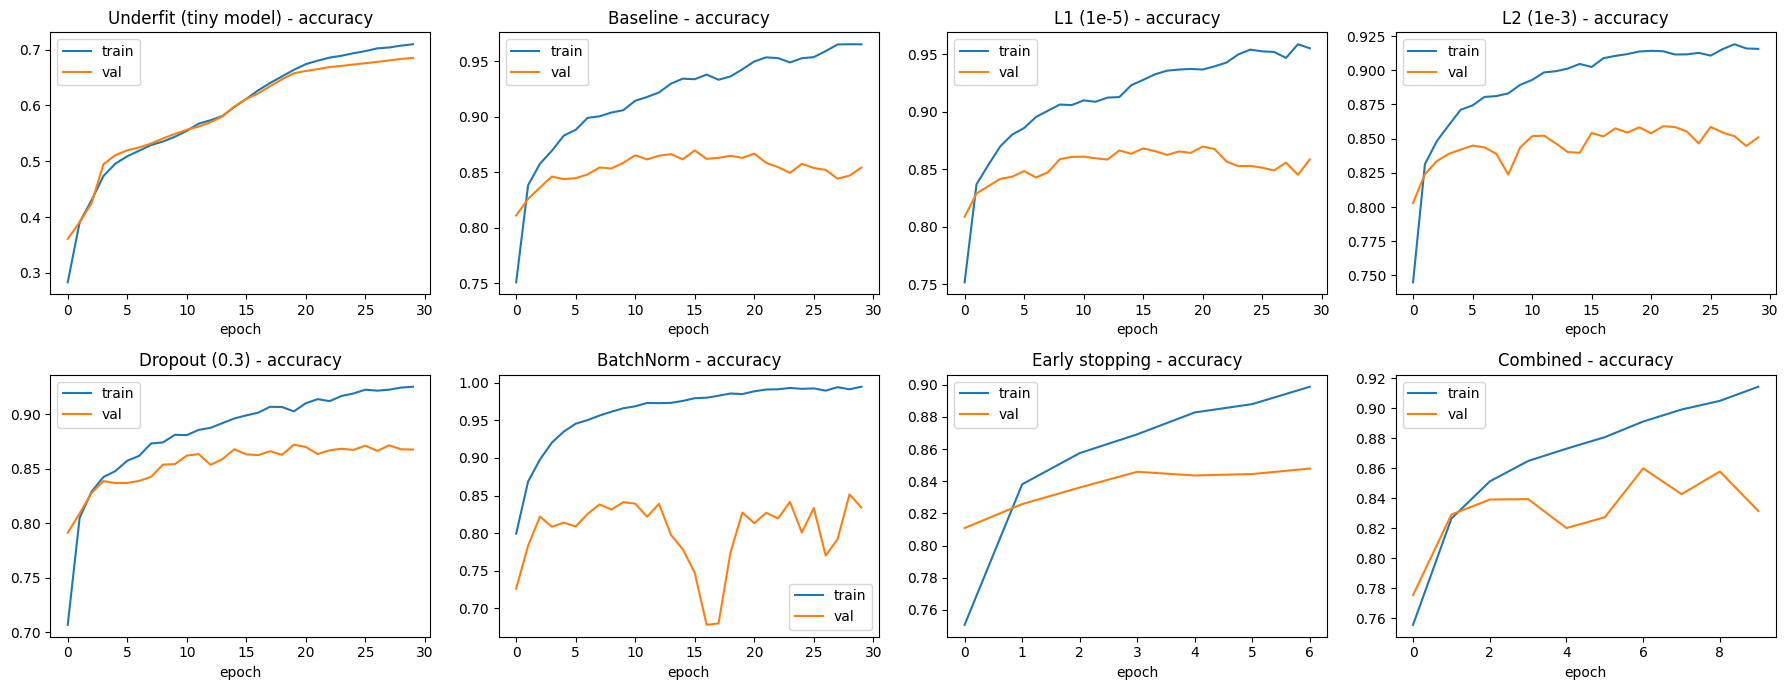

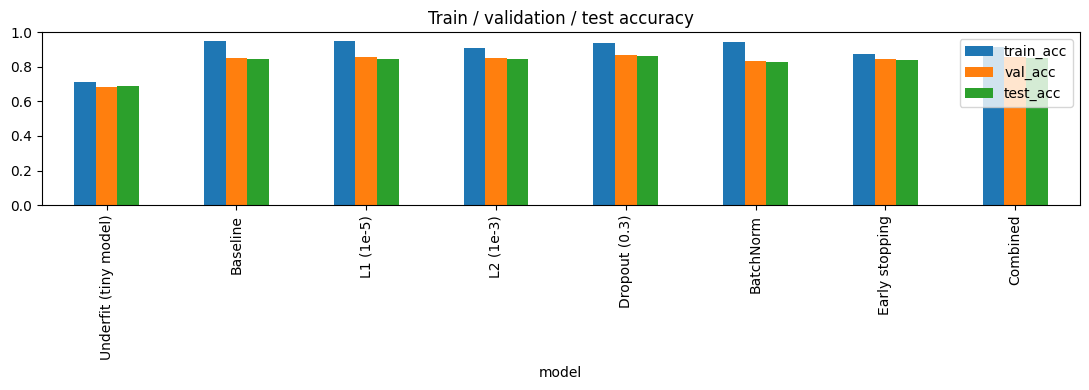

In [9]:
df = pd.DataFrame(results)
display(df)

def curves(key):
    fig, ax = plt.subplots(2, 4, figsize=(18, 7))
    for a, (name, h) in zip(ax.ravel(), hist.items()):
        a.plot(h[key], label="train"); a.plot(h["val_" + key], label="val")
        a.set_title(f"{name} - {key}"); a.set_xlabel("epoch"); a.legend()
    plt.tight_layout(); plt.show()
curves("loss"); curves("accuracy")

df.set_index("model")[["train_acc", "val_acc", "test_acc"]].plot.bar(
    figsize=(11, 4), ylim=(0.0, 1.0), title="Train / validation / test accuracy")
plt.tight_layout(); plt.show()